In [43]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [44]:
%pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [45]:
# load all sheets into a dictionary of dataframes
dfs = pd.read_excel(r'../data/raw/VRP_Sri_Lanka_Dataset.xlsx', sheet_name=None)
print(dfs)
# Delivery_Order sheet
delivery_orders = dfs['Delivery_Orders']

# Vehicle_Fleet sheet
vehicle_fleet = dfs['Vehicle_Fleet']

# Road_Speed_Lookup sheet
road_speed_lookup = dfs['Road_Speed_Lookup']

print("Successfully loaded all sheets into dataframes.")

{'Delivery_Orders':     Order_ID         City_Name       Province  Latitude  Longitude  \
0    ORD-000           Colombo        Western    6.9271    79.8612   
1    ORD-001            Mannar       Northern    8.9930    79.9039   
2    ORD-002          Ahangama       Southern    5.9601    80.3600   
3    ORD-003    Tissamaharama        Southern    6.2808    81.2885   
4    ORD-004          PANADURA        Western    6.7073    79.8970   
..       ...               ...            ...       ...        ...   
195  ORD-127     Tissamaharama       Southern    6.2805    81.2894   
196  ORD-096         Wattegama        Central    7.3273    80.6507   
197  ORD-028         Hikkaduwa       Southern    6.1389    80.0967   
198  ORD-162            Ja-Ela        Western    7.0695    79.8981   
199  ORD-119          KEKIRAWA  North Central    8.0344    80.5699   

    Cargo_Weight_kg Road_Condition Priority_Level  Order_Value_LKR  \
0                 0      Excellent              0              0.0   

In [46]:
print("==================================================")
print("         DIAGNOSTIC & STRING CORRUPTION           ")
print("==================================================")

# Audit Priority level
print("Auditing Priority levels in Delivery_Orders sheet...")
print(delivery_orders['Priority_Level'].value_counts(dropna=False))

# Audit cargo weight
print("Auditing Cargo_Weight in Delivery_Orders sheet...")
corrupted_cargo_weight = delivery_orders[pd.to_numeric(delivery_orders['Cargo_Weight_kg'], errors='coerce').isnull() & delivery_orders['Cargo_Weight_kg'].notnull()]
if not corrupted_cargo_weight.empty:
    display(corrupted_cargo_weight[['Order_ID', 'Cargo_Weight_kg','City_Name']].head(10))
else:
    print("No corrupted Cargo_Weight_kg values found.")

# Audit Order value
print("Auditing Order_Value_LKR in Delivery_Orders sheet...")
corrupted_order_value = delivery_orders[pd.to_numeric(delivery_orders['Order_Value_LKR'], errors ='coerce').isnull() & delivery_orders['Order_Value_LKR'].notnull()]
if not corrupted_order_value.empty:
    display(corrupted_order_value[['Order_ID', 'Order_Value_LKR','City_Name']].head(10))
else:
    print("No corrupted Order_Value_LKR values found.")

         DIAGNOSTIC & STRING CORRUPTION           
Auditing Priority levels in Delivery_Orders sheet...
Priority_Level
3       67
4       40
2       34
5       28
1       25
High     3
6        2
0        1
Name: count, dtype: int64
Auditing Cargo_Weight in Delivery_Orders sheet...


,Order_ID,Cargo_Weight_kg,City_Name
59,ORD-059,2089 kg,Peliyagoda
134,ORD-134,997 kg,Panadura
140,ORD-140,2176 kg,Kayts
144,ORD-144,1923 kg,Welimada
154,ORD-154,1087 kg,Dehiwala
190,ORD-190,1215 kg,Ratnapura


Auditing Order_Value_LKR in Delivery_Orders sheet...
No corrupted Order_Value_LKR values found.


In [47]:
print("==================================================")
print("             EXECUTE TYPE ENFORCEMENT             ")
print("==================================================")

# Clean priority level
delivery_orders['Priority_Level'] = delivery_orders['Priority_Level'].replace({'High': 5, 'high': 5})

# any remaining nulls or text values, fill or handle them before integer conversion
delivery_orders['Priority_Level'] = pd.to_numeric(delivery_orders['Priority_Level'], errors='coerce').fillna(0).astype(int)
print("Priority_Level column cleaned and converted to integer.")

# Numeric conversion for Cargo_Weight_kg and Order_Value_LKR
delivery_orders['Cargo_Weight_kg'] = delivery_orders['Cargo_Weight_kg'].astype(str).str.lower().str.replace('kg', '').str.replace(',', '').str.strip()
delivery_orders['Cargo_Weight_kg'] = pd.to_numeric(delivery_orders['Cargo_Weight_kg'], errors='coerce')
print("Cargo_Weight_kg column cleaned and converted to numeric.")

delivery_orders['Order_Value_LKR'] = delivery_orders['Order_Value_LKR'].astype(str).str.lower().str.replace('lkr', '').str.replace(',', '').str.strip()
delivery_orders['Order_Value_LKR'] = pd.to_numeric(delivery_orders['Order_Value_LKR'], errors='coerce')
print("Order_Value_LKR column cleaned and converted to numeric.")


print("Post transformation data types:")
print(delivery_orders[['Priority_Level', 'Cargo_Weight_kg', 'Order_Value_LKR']].dtypes)

             EXECUTE TYPE ENFORCEMENT             
Priority_Level column cleaned and converted to integer.
Cargo_Weight_kg column cleaned and converted to numeric.
Order_Value_LKR column cleaned and converted to numeric.
Post transformation data types:
Priority_Level       int64
Cargo_Weight_kg    float64
Order_Value_LKR    float64
dtype: object


C:\Users\User\AppData\Local\Temp\ipykernel_39788\2785376883.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  delivery_orders['Priority_Level'] = delivery_orders['Priority_Level'].replace({'High': 5, 'high': 5})


        DIAGNOSTIC & SPATIAL IDENTIFICATION       
Checking for duplicates in city names in Delivery_Orders sheet...
City_Name
Kegalle          5
Kalutara         5
Wattegama        5
Ambalangoda      5
Kotte            5
Matale           4
Valachchenai     4
Ahangama         4
Dehiwala         4
Tissamaharama    4
Name: count, dtype: int64
Checking for gaps in cargo weight in Delivery_Orders sheet...


,Order_ID,City_Name,Province,Cargo_Weight_kg
15,ORD-015,Beliatta,Southern,NaN
27,ORD-027,Polonnaruwa,North Central,NaN
38,ORD-038,Hikkaduwa,Southern,NaN
51,ORD-051,Mount Lavinia,Western,NaN
63,ORD-063,Maharagama,Western,NaN
66,ORD-066,Beliatta,Southern,NaN
69,ORD-069,Wattegama,Central,NaN
76,ORD-076,Kaduwela,Western,NaN
95,ORD-095,Badulla,Uva,NaN
96,ORD-096,Wattegama,Central,NaN


Visualizing the imputation strategy for missing cargo weights using province medians...


,Province,Cargo_Weight_kg
0,Central,1664.0
1,Eastern,1662.5
2,North Central,2104.0
3,North Western,2067.0
4,Northern,1705.0
5,Sabaragamuwa,1817.0
6,Southern,1818.0
7,Uva,1743.0
8,Western,1428.0
9,eastern,850.0


C:\Users\User\AppData\Local\Temp\ipykernel_39788\1072514311.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=province_medians, x='Province', y='Cargo_Weight_kg', palette='viridis')


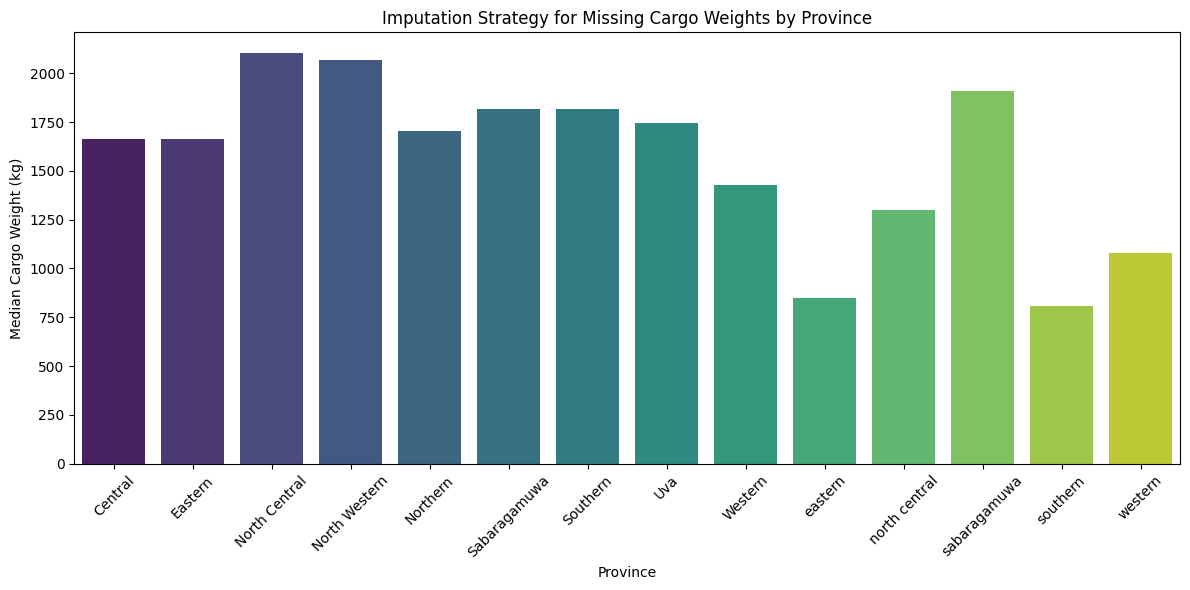

In [48]:
print("==================================================")
print("        DIAGNOSTIC & SPATIAL IDENTIFICATION       ")
print("==================================================")

# Identify anomalies in the data
print("Checking for duplicates in city names in Delivery_Orders sheet...")
delivery_orders_duplicates = delivery_orders['City_Name'].value_counts().head(10)
print(delivery_orders_duplicates)


# Gaps in cargo weight
print("Checking for gaps in cargo weight in Delivery_Orders sheet...")
missing_cargo_weight = delivery_orders[delivery_orders['Cargo_Weight_kg'].isnull()]
display(missing_cargo_weight[['Order_ID', 'City_Name', 'Province', 'Cargo_Weight_kg']])


# Visualize the Imputation Strategy province medians
print("Visualizing the imputation strategy for missing cargo weights using province medians...")
province_medians = delivery_orders.groupby('Province')['Cargo_Weight_kg'].median().reset_index()
display(province_medians)

plt.figure(figsize=(12, 6))
sns.barplot(data=province_medians, x='Province', y='Cargo_Weight_kg', palette='viridis')
plt.title('Imputation Strategy for Missing Cargo Weights by Province')
plt.xlabel('Province')
plt.ylabel('Median Cargo Weight (kg)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [49]:
print("==================================================")
print("             EXECUTE TYPE ENFORCEMENT             ")
print("==================================================")

# text standarization
delivery_orders['City_Name'] = delivery_orders['City_Name'].str.title().str.strip()
print("City_Name column standardized to title case and stripped")

# Inject the province median cargo weight into the missing values
delivery_orders['Cargo_Weight_kg'] = delivery_orders['Cargo_Weight_kg'].fillna(delivery_orders.groupby('Province')['Cargo_Weight_kg'].transform('median'))
print("Missing cargo weight values filled with province median values")

print("Post Transformation Verification:")
verified_missing_cargo_weight = delivery_orders[delivery_orders['Order_ID'].isin(['ORD-007', 'ORD-032'])]
display(verified_missing_cargo_weight[['Order_ID', 'City_Name', 'Province', 'Cargo_Weight_kg']])


             EXECUTE TYPE ENFORCEMENT             
City_Name column standardized to title case and stripped
Missing cargo weight values filled with province median values
Post Transformation Verification:


,Order_ID,City_Name,Province,Cargo_Weight_kg
7,ORD-007,Nuwara Eliya,Central,1608.0
32,ORD-032,Ahangama,Southern,1387.0


In [50]:
print("==================================================")
print("           DIAGNOSTIC CAPACITY IMPUTATION         ")
print("==================================================")

# Isolate the Blanks
print("Orders with missing Cargo Weight:")
missing_cargo_orders = delivery_orders[delivery_orders['Cargo_Weight_kg'].isnull()]
if not missing_cargo_orders.empty:
    display(missing_cargo_orders[['Order_ID', 'City_Name', 'Province', 'Cargo_Weight_kg']])
else:
    print("No orders with missing Cargo Weight found.")
    
    
# Calculate the medians by province for imputation
province_medians = delivery_orders.groupby('Province')['Cargo_Weight_kg'].median().reset_index()
province_medians.rename(columns={'Cargo_Weight_kg': 'Median_Weight_kg'}, inplace=True)
display(province_medians)

           DIAGNOSTIC CAPACITY IMPUTATION         
Orders with missing Cargo Weight:
No orders with missing Cargo Weight found.


,Province,Median_Weight_kg
0,Central,1664.0
1,Eastern,1662.5
2,North Central,2104.0
3,North Western,2067.0
4,Northern,1705.0
5,Sabaragamuwa,1817.0
6,Southern,1818.0
7,Uva,1743.0
8,Western,1428.0
9,eastern,850.0


In [51]:
print("==================================================")
print("             EXECUTE CAPACITY IMPUTATION          ")
print("==================================================")

# Fill missing Cargo_Weight_kg values with the median weight of their respective provinces
delivery_orders['Cargo_Weight_kg'] = delivery_orders['Cargo_Weight_kg'].fillna(delivery_orders.groupby('Province')['Cargo_Weight_kg'].transform('median'))
print("Missing Cargo_Weight_kg values filled with province median values.")

# Verification of imputation
print("Post-Imputation Verification:")
print(f"Number of missing Cargo_Weight_kg values remaining: {delivery_orders['Cargo_Weight_kg'].isnull().sum()}")

             EXECUTE CAPACITY IMPUTATION          
Missing Cargo_Weight_kg values filled with province median values.
Post-Imputation Verification:
Number of missing Cargo_Weight_kg values remaining: 0


In [52]:
print("==================================================")
print("           DIAGNOSTIC REVENUE IMPUTATION          ")
print("==================================================")

# Isolate the Blanks
print("Orders with missing Order Value:")
missing_order_value_orders = delivery_orders[delivery_orders['Order_Value_LKR'].isnull()]
if not missing_order_value_orders.empty:
    display(missing_order_value_orders[['Order_ID', 'City_Name', 'Province', 'Order_Value_LKR']])
else:
    print("No orders with missing Order Value found.")


# preview the medians by priority level for imputation
priority_medians = delivery_orders.groupby('Priority_Level')['Order_Value_LKR'].median().reset_index()
priority_medians.rename(columns={'Order_Value_LKR': 'Median_Order_Value_LKR'}, inplace=True)
display(priority_medians)

           DIAGNOSTIC REVENUE IMPUTATION          
Orders with missing Order Value:


,Order_ID,City_Name,Province,Order_Value_LKR
26,ORD-026,Chavakachcheri,Northern,NaN
35,ORD-035,Beruwala,Western,NaN
45,ORD-045,Tangalle,Southern,NaN
46,ORD-046,Welimada,Uva,NaN
57,ORD-057,Tangalle,Southern,NaN
110,ORD-110,Matale,Central,NaN
111,ORD-111,Valachchenai,Eastern,NaN
136,ORD-136,Nawalapitiya,Central,NaN
165,ORD-165,Kaduwela,Western,NaN
172,ORD-172,Kuliyapitiya,North Western,NaN


,Priority_Level,Median_Order_Value_LKR
0,0,0.0
1,1,8550.0
2,2,14550.0
3,3,22000.0
4,4,33100.0
5,5,48700.0
6,6,33600.0


In [53]:
print("==================================================")
print("            EXECUTE REVENUE IMPUTATION            ")
print("==================================================")

# Fill missing Order_Value_LKR values with the median value of their respective priority levels
delivery_orders['Order_Value_LKR'] = delivery_orders['Order_Value_LKR'].fillna(delivery_orders.groupby('Priority_Level')['Order_Value_LKR'].transform('median'))
print("Missing Order_Value_LKR values filled with priority level median values.")

# Verification of imputation
print("Post-Imputation Verification:")
print(f"Number of missing Order_Value_LKR values remaining: {delivery_orders['Order_Value_LKR'].isnull().sum()}")

            EXECUTE REVENUE IMPUTATION            
Missing Order_Value_LKR values filled with priority level median values.
Post-Imputation Verification:
Number of missing Order_Value_LKR values remaining: 0


In [54]:
print("==================================================")
print("       DIAGNOSTIC SERVICE TIME IMPUTATION         ")
print("==================================================")

# Isolate the Blanks
print("Orders with missing Service Time:")
missing_service_time_orders = delivery_orders[delivery_orders['Service_Time_min'].isnull()]

if not missing_service_time_orders.empty:
    display(missing_service_time_orders[['Order_ID', 'City_Name', 'Province', 'Service_Time_min']])
else:
    print("No orders with missing Service Time found.")
    
# Caluculate the global median service time for imputation
global_median_service_time = delivery_orders['Service_Time_min'].median()
print(f"Global median service time calculated: {global_median_service_time} minutes")

       DIAGNOSTIC SERVICE TIME IMPUTATION         
Orders with missing Service Time:


,Order_ID,City_Name,Province,Service_Time_min
21,ORD-021,Matale,Central,NaN
22,ORD-022,Mahiyanganaya,Uva,NaN
42,ORD-042,Tissamaharama,Southern,NaN
115,ORD-115,Kuliyapitiya,North Western,NaN
120,ORD-120,Galle,Southern,NaN
128,ORD-128,Galle,Southern,NaN
151,ORD-151,Puttalam,North Western,NaN
184,ORD-184,Balangoda,Sabaragamuwa,NaN


Global median service time calculated: 27.5 minutes


In [55]:
print("==================================================")
print("         EXECUTE SERVICE TIME IMPUTATION          ")
print("==================================================")

# Fill missing Service_Time_min values with the global median service time
delivery_orders['Service_Time_min'] = delivery_orders['Service_Time_min'].fillna(global_median_service_time)
print("Missing Service_Time_min values filled with global median service time.")

# Verification of imputation
print("Post-Imputation Verification:")
print(f"Number of missing Service_Time_min values remaining: {delivery_orders['Service_Time_min'].isnull().sum()}")

         EXECUTE SERVICE TIME IMPUTATION          
Missing Service_Time_min values filled with global median service time.
Post-Imputation Verification:
Number of missing Service_Time_min values remaining: 0


In [56]:
print("==================================================")
print("   DIAGNOSTIC TEXT STANDARDIZATION & CLEANING     ")
print("==================================================")

# Unique provinces
unique_provinces = delivery_orders['Province'].value_counts(dropna=False)
print(unique_provinces)

# unique road_conditions
unique_road_conditions = delivery_orders['Road_Condition'].value_counts(dropna=False)
print(unique_road_conditions)

   DIAGNOSTIC TEXT STANDARDIZATION & CLEANING     
Province
Western          55
Southern         37
Central          24
Northern         18
Uva              16
Sabaragamuwa     14
Eastern          11
North Central     8
North Western     8
sabaragamuwa      3
western           3
eastern           1
north central     1
southern          1
Name: count, dtype: int64
Road_Condition
Winding       36
Expressway    30
Traffic       28
Highway       26
Good          25
Mountain      22
Excellent     21
traffic        4
expressway     4
mountain       1
winding        1
excellent      1
highway        1
Name: count, dtype: int64


In [57]:
print("==================================================")
print("    EXECUTE TEXT STANDARDIZATION & CLEANING       ")
print("==================================================")

# Fix the Province Casing Inconsistency
delivery_orders['Province'] = delivery_orders['Province'].str.title().str.strip()
print("Province column standardized to title case and stripped.")

# Force lowercase and strip leading/trailing whitespace in one chained command
delivery_orders['Road_Condition'] = delivery_orders['Road_Condition'].str.lower().str.strip()
print("Road_Condition column standardized to lowercase and stripped.")

# Strip out 'kg', 'Kg', commas, and extra spaces
delivery_orders['Cargo_Weight_kg'] = delivery_orders['Cargo_Weight_kg'].astype(str).str.lower().str.replace('kg', '').str.replace(',', '').str.strip()
print("Cargo_Weight_kg column cleaned of 'kg', commas, and extra spaces.")

    EXECUTE TEXT STANDARDIZATION & CLEANING       
Province column standardized to title case and stripped.
Road_Condition column standardized to lowercase and stripped.
Cargo_Weight_kg column cleaned of 'kg', commas, and extra spaces.


In [58]:
print("==================================================")
print("         DIAGNOSTIC TIME WINDOW PARSING           ")
print("==================================================")

# Identify missing delivery window start and end times
missing_start_times = delivery_orders[delivery_orders['Delivery_Window_Start'].isnull()]
print(f"Orders with missing Delivery Window Start times: {len(missing_start_times)}")

missing_end_times = delivery_orders[delivery_orders['Delivery_Window_End'].isnull()]
print(f"Orders with missing Delivery Window End times: {len(missing_end_times)}")

         DIAGNOSTIC TIME WINDOW PARSING           
Orders with missing Delivery Window Start times: 7
Orders with missing Delivery Window End times: 7


In [59]:
print("==================================================")
print("         EXECUTE TIME WINDOW PARSING              ")
print("==================================================")

#  Fill the missing time windows with default midnight and 11:59 PM values
delivery_orders['Delivery_Window_Start'] = delivery_orders['Delivery_Window_Start'].fillna('00:00')
delivery_orders['Delivery_Window_End'] = delivery_orders['Delivery_Window_End'].fillna('23:59')
print("Missing Delivery_Window_Start and Delivery_Window_End values filled with default times.")

# Parse and Convert 'Delivery_Window_Start'
start_time_parsed = delivery_orders['Delivery_Window_Start'].astype(str).str.split(':', expand=True)
# Multiply hours by 60 and add the minutes
delivery_orders['Delivery_Window_Start'] = (start_time_parsed[0].astype(int) * 60) + start_time_parsed[1].astype(int)

# Parse and Convert 'Delivery_Window_End'
end_time_parsed = delivery_orders['Delivery_Window_End'].astype(str).str.split(':', expand=True)
# Multiply hours by 60 and add the minutes
delivery_orders['Delivery_Window_End'] = (end_time_parsed[0].astype(int) * 60) + end_time_parsed[1].astype(int) 

print("Delivery_Window_Start and Delivery_Window_End columns parsed and converted to total minutes since midnight.")

# Verification of parsing
print("Post-Parsing Verification:")
display(delivery_orders[['Order_ID', 'Delivery_Window_Start', 'Delivery_Window_End']].head(10))

# Data types verification
print("Data types after parsing:")
print(delivery_orders[['Delivery_Window_Start', 'Delivery_Window_End']].dtypes)

         EXECUTE TIME WINDOW PARSING              
Missing Delivery_Window_Start and Delivery_Window_End values filled with default times.
Delivery_Window_Start and Delivery_Window_End columns parsed and converted to total minutes since midnight.
Post-Parsing Verification:


,Order_ID,Delivery_Window_Start,Delivery_Window_End
0,ORD-000,0,0
1,ORD-001,780,1020
2,ORD-002,480,720
3,ORD-003,780,1020
4,ORD-004,780,1020
5,ORD-005,0,1439
6,ORD-006,480,1020
7,ORD-007,480,720
8,ORD-008,840,1080
9,ORD-009,720,960


Data types after parsing:
Delivery_Window_Start    int64
Delivery_Window_End      int64
dtype: object


In [60]:
# SPATIAL IMPUTATION
delivery_orders['Latitude'] = delivery_orders['Latitude'].fillna(delivery_orders.groupby('City_Name')['Latitude'].transform('first'))
delivery_orders['Longitude'] = delivery_orders['Longitude'].fillna(delivery_orders.groupby('City_Name')['Longitude'].transform('first'))

# fallback to exact lat and longs
fallback_lat_long = {
    'Akurana': [7.3621, 80.6214],
    'Ambalangoda': [6.2355, 80.0538],
    'Ampara': [7.2917, 81.6722],
    'Anuradhapura': [8.3114, 80.4037],
    'Avissawella': [6.9553, 80.2112],
    'Badulla': [6.9934, 81.0550],
    'Balangoda': [6.6615, 80.6934],
    'Bandarawela': [6.8301, 80.9853],
    'Batticaloa': [7.7102, 81.6924],
    'Beruwala': [6.4788, 79.9828],
    'Chavakachcheri': [9.6615, 80.1653],
    'Chilaw': [7.5758, 79.7953],
    'Colombo': [6.9271, 79.8612],
    'Dambulla': [7.8731, 80.6517],
    'Dehiwala-Mount Lavinia': [6.8510, 79.8653],
    'Embilipitiya': [6.3439, 80.8489],
    'Galle': [6.0329, 80.2168],
    'Gampaha': [7.0873, 79.9994],
    'Hambantota': [6.1241, 81.1185],
    'Hatton': [6.8916, 80.5955],
    'Homagama': [6.8440, 80.0047],
    'Horana': [6.7159, 80.0626],
    'Jaffna': [9.6615, 80.0255],
    'Kalmunai': [7.4167, 81.8167],
    'Kalutara': [6.5854, 79.9607],
    'Kandy': [7.2906, 80.6337],
    'Kegalle': [7.2513, 80.3464],
    'Kelaniya': [6.9553, 79.9220],
    'Kilinochchi': [9.3961, 80.3982],
    'Kolonnawa': [6.9329, 79.8848],
    'Kuliyapitiya': [7.4688, 80.0401],
    'Kurunegala': [7.4863, 80.3647],
    'Maharagama': [6.8480, 79.9265],
    'Mannar': [8.9770, 79.9044],
    'Matale': [7.4675, 80.6234],
    'Matara': [5.9549, 80.5550],
    'Minuwangoda': [7.1667, 79.9500],
    'Monaragala': [6.8725, 81.3507],
    'Moratuwa': [6.7730, 79.8826],
    'Mullaitivu': [9.2671, 80.8142],
    'Negombo': [7.2083, 79.8358],
    'Nawalapitiya': [7.0500, 80.5333],
    'Nuwara Eliya': [6.9497, 80.7891],
    'Panadura': [6.7132, 79.9026],
    'Peliyagoda': [6.9685, 79.8836],
    'Point Pedro': [9.8167, 80.2333],
    'Polonnaruwa': [7.9403, 81.0188],
    'Puttalam': [8.0362, 79.8283],
    'Ratnapura': [6.6828, 80.3992],
    'Sri Jayawardenepura Kotte': [6.8941, 79.9025],
    'Tangalle': [6.0243, 80.7974],
    'Trincomalee': [8.5874, 81.2152],
    'Valvettithurai': [9.8167, 80.1667],
    'Vavuniya': [8.7514, 80.4971],
    'Wattala': [6.9892, 79.8917],
    'Weligama': [5.9745, 80.4298],
    'Welimada': [6.9062, 80.9131]
}

# Apply any remaining missing latitudes and longitudes using the fallback dictionary
for city, coords in fallback_lat_long.items():
    delivery_orders.loc[(delivery_orders['City_Name'] == city) & (delivery_orders['Latitude'].isnull()), 'Latitude'] = coords[0]
    delivery_orders.loc[(delivery_orders['City_Name'] == city) & (delivery_orders['Longitude'].isnull()), 'Longitude'] = coords[1]
    
print("Missing Latitude and Longitude values filled using fallback dictionary.")

# Node consolidation: Group by City_Name and aggregate the necessary fields
aggregate_rules = {
    'Order_ID': lambda x: ' | '.join(x),
    'Cargo_Weight_kg': 'sum',
    'Order_Value_LKR': 'sum',
    'Priority_Level': 'max',
    'Service_Time_min': 'sum',
    'Delivery_Window_Start': 'max',
    'Delivery_Window_End': 'min'
}

# execute the aggregation and merge
original_count = len(delivery_orders)
delivery_orders = delivery_orders.groupby(['City_Name', 'Province', 'Latitude', 'Longitude', 'Road_Condition'], sort = False, as_index=False).agg(aggregate_rules)

new_count = len(delivery_orders)
print(f"Original count: {original_count}, New count: {new_count}")
print("Node consolidation completed. Orders have been aggregated by City_Name, Province, Latitude, Longitude, and Road_Condition.")

# Rearrange columns
final_columns = ['Order_ID', 'City_Name', 'Province', 'Latitude', 'Longitude', 'Cargo_Weight_kg', 
                 'Road_Condition', 'Priority_Level', 'Order_Value_LKR', 'Service_Time_min', 
                 'Delivery_Window_Start', 'Delivery_Window_End']
delivery_orders = delivery_orders[final_columns]

Missing Latitude and Longitude values filled using fallback dictionary.
Original count: 200, New count: 192
Node consolidation completed. Orders have been aggregated by City_Name, Province, Latitude, Longitude, and Road_Condition.


In [61]:
print("==================================================")
print("         DIAGNOSTIC MATRICES PREPARATION          ")
print("==================================================")

# Array Dimensions
n_nodes = len(delivery_orders)
print(f"Number of nodes (n_nodes): {n_nodes}")
print(f'Expected Matrix Shape: ({n_nodes} x {n_nodes})')

# Audit Speed multiplier values in the Road_Speed_Lookup sheet
print("Auditing Speed_Multiplier values in Road_Speed_Lookup sheet...")
road_speed_lookup['Avg_Speed_kmph'] = pd.to_numeric(road_speed_lookup['Avg_Speed_kmph'], errors='coerce')
display(road_speed_lookup[['Road_Condition', 'Avg_Speed_kmph']].head(10))

# Check for unmatched road conditions in our delivery_orders
lookup_conditions = road_speed_lookup['Road_Condition'].unique()
order_conditions = delivery_orders['Road_Condition'].unique()
unmatched_conditions = [cond for cond in order_conditions if cond not in lookup_conditions]
if unmatched_conditions:
    print(f"Unmatched Road Conditions found in Delivery_Orders: {unmatched_conditions}")
else:
    print("All Road Conditions in Delivery_Orders match those in Road_Speed_Lookup.")

         DIAGNOSTIC MATRICES PREPARATION          
Number of nodes (n_nodes): 192
Expected Matrix Shape: (192 x 192)
Auditing Speed_Multiplier values in Road_Speed_Lookup sheet...


,Road_Condition,Avg_Speed_kmph
0,Expressway,90.0
1,Highway,70.0
2,Good,55.0
3,Traffic,25.0
4,Winding,40.0
5,Mountain,30.0
6,Excellent,100.0
7,Note:,NaN


Unmatched Road Conditions found in Delivery_Orders: ['excellent', 'traffic', 'mountain', 'highway', 'winding', 'good', 'expressway']


In [62]:
print("==================================================")
print("         EXECUTING MATHEMATICAL MATRICES          ")
print("==================================================")

# 1D arrays for the matrices
cargo_weights = delivery_orders['Cargo_Weight_kg'].to_numpy()
order_values = delivery_orders['Order_Value_LKR'].to_numpy()
service_times = delivery_orders['Service_Time_min'].to_numpy()
window_starts = delivery_orders['Delivery_Window_Start'].to_numpy()
window_ends = delivery_orders['Delivery_Window_End'].to_numpy()
print("1D arrays for Cargo Weights, Order Values, Service Times, and Delivery Windows created.")

# 2D arrays for the matrices
# Convert coordinates to radius
latitudes = delivery_orders['Latitude'].to_numpy()
longitudes = delivery_orders['Longitude'].to_numpy()

# vectorized differences
latitude_diff = latitudes[:, np.newaxis] - latitudes
longitude_diff = longitudes[:, np.newaxis] - longitudes

# Haversine formula for distance calculation
R = 6371  # Earth radius in kilometers
a = (np.sin(latitude_diff / 2)**2 + 
     np.cos(latitudes[:, np.newaxis]) * np.cos(latitudes) * np.sin(longitude_diff / 2)**2)
c = 2 * np.arcsin(np.sqrt(a))
distance_matrix_km = R * c
print("Distance matrix calculated using Haversine formula.")

# Apply speed multipliers based on road conditions
multiplier_dict = dict(zip(road_speed_lookup['Road_Condition'], road_speed_lookup['Avg_Speed_kmph']))

destination_conditions = delivery_orders['Road_Condition'].to_numpy()

destination_multipliers = np.array([multiplier_dict.get(cond, 1.0) for cond in destination_conditions])

# Multiply the distance by the destination's multiplier
time_cost_matrix = distance_matrix_km * destination_multipliers[np.newaxis, :]
np.fill_diagonal(time_cost_matrix, 0.0)  # Set diagonal to zero 
print("Time cost matrix calculated by applying speed multipliers based on road conditions.")


# save processed data and final matrices
project_root = os.path.dirname(os.getcwd())
output_dir = os.path.join(project_root, 'data', 'processed')
os.makedirs(output_dir, exist_ok=True)

data_set = os.path.join(output_dir, 'cleaned_delivery_orders.csv')
delivery_orders.to_csv(data_set, index=False)

# save matrices
matrices_path = os.path.join(output_dir, 'vrp_mathematical_matrices.npz')
np.savez(matrices_path,
         cargo_weights=cargo_weights,
         order_values=order_values,
         service_times=service_times,
         window_starts=window_starts,
         window_ends=window_ends,
         distance_matrix_km=distance_matrix_km,
         time_cost_matrix=time_cost_matrix)

print(f"Processed dataset saved to {data_set}")
print(f"Mathematical matrices saved to {matrices_path}")
print("Data preparation and matrix generation completed successfully.")

         EXECUTING MATHEMATICAL MATRICES          
1D arrays for Cargo Weights, Order Values, Service Times, and Delivery Windows created.
Distance matrix calculated using Haversine formula.
Time cost matrix calculated by applying speed multipliers based on road conditions.


Processed dataset saved to g:\My Drive\MSC\Machine Learning\Assignment\Q3_Route_Scheduler\data\processed\cleaned_delivery_orders.csv
Mathematical matrices saved to g:\My Drive\MSC\Machine Learning\Assignment\Q3_Route_Scheduler\data\processed\vrp_mathematical_matrices.npz
Data preparation and matrix generation completed successfully.
